# Exploring Data

First, install the required Python libraries if not done already. See
[Installing Required Python Libraries](../00_Installing_Required_Python_Libraries.md).

In this notebook we will explore our customer churn dataset to try to identify whether there are any meaningful relationships between our variables. We will also attempt to identify any data quality issues that will need to be addressed prior to developing machine learning models. 

### Imports

In the next section we will import the necessary packages and modules that will be used throughout this project.

In [1]:
# Imports necessary packages and modules

import matplotlib.pyplot as plt 
from math import ceil
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import seaborn as sns 

In [2]:
# Imports the dataset 

churn_df = pd.read_csv("../../data/output/customer_churn_abt.csv", header="infer")

### Basic Exploration

Explores some of the basic information pertaining to the data.

In [3]:
# Displays some information pertaining to the churn dataset

churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      5000 non-null   float64
 1   LostCustomer            5000 non-null   float64
 2   regionPctCustomers      5000 non-null   float64
 3   numOfTotalReturns       5000 non-null   float64
 4   wksSinceLastPurch       5000 non-null   float64
 5   basktPurchCount12Month  5000 non-null   float64
 6   LastPurchaseAmount      5000 non-null   float64
 7   AvgPurchaseAmount12     5000 non-null   float64
 8   AvgPurchaseAmountTotal  5000 non-null   float64
 9   intAdExposureCount12    5000 non-null   float64
 10  intAdExposureCount36    5000 non-null   float64
 11  intAdExposureCountAll   5000 non-null   float64
 12  socialMediaAdCount12    5000 non-null   float64
 13  socialMediaAdCount36    5000 non-null   float64
 14  socialMediaAdCountAll   5000 non-null   

In [4]:
# Display the column variable types

dtypes = churn_df.dtypes.value_counts()
dtypes

float64    25
object      6
Name: count, dtype: int64

### Duplicate Rows

Checks and removes duplicate rows if they exists.

In [5]:
# Checks and drops duplicate rows

churn_df = churn_df.drop_duplicates(keep = "first")
churn_df.shape

(5000, 31)

### Exploring Distributions

In [6]:
# Displays summary statistics for the numeric and categorical columns

for _type in dtypes.index:
    print(f"----------Variable Summary Statistics for {_type} variables----------", end = "\n\n")
    display(churn_df.describe(include = _type).T)
    print("", end = "\n\n")

----------Variable Summary Statistics for float64 variables----------



,count,mean,std,min,25%,50%,75%,max
ID,5000.0,83232.127600,59084.633099,110.00,44128.250000,71525.500,132047.500000,191766.000000
LostCustomer,5000.0,0.113800,0.317600,0.00,0.000000,0.000,0.000000,1.000000
regionPctCustomers,5000.0,31.279200,11.474702,0.00,25.000000,31.000,38.000000,76.000000
numOfTotalReturns,5000.0,1.500800,1.484197,0.00,0.000000,1.000,2.000000,9.000000
wksSinceLastPurch,5000.0,17.942600,4.653992,4.00,16.000000,18.000,20.000000,27.000000
basktPurchCount12Month,5000.0,3.415800,1.737905,1.00,2.000000,3.000,5.000000,10.000000
LastPurchaseAmount,5000.0,94.539740,119.455693,0.00,50.000000,75.000,100.000000,5000.000000
AvgPurchaseAmount12,5000.0,85.524630,81.084966,0.00,52.837500,75.000,100.000000,2500.000000
AvgPurchaseAmountTotal,5000.0,71.981600,62.077423,9.40,45.000000,62.000,82.500000,1714.300000
intAdExposureCount12,5000.0,13.522200,5.743736,2.00,11.000000,13.000,14.000000,48.000000




----------Variable Summary Statistics for object variables----------



,count,unique,top,freq
customerGender,5000,3,F,2637
birthDate,3741,2867,2002-07-14,5
customerSubscrStat,5000,3,Platinum,3945
Review_Text,782,782,If you are afraid of the jumpsuit trend but li...,1
Title,672,630,Nice top,4
demHomeOwner,5000,2,HomeOwner,2756


array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'LostCustomer'}>,
        <Axes: title={'center': 'regionPctCustomers'}>,
        <Axes: title={'center': 'numOfTotalReturns'}>,
        <Axes: title={'center': 'wksSinceLastPurch'}>],
       [<Axes: title={'center': 'basktPurchCount12Month'}>,
        <Axes: title={'center': 'LastPurchaseAmount'}>,
        <Axes: title={'center': 'AvgPurchaseAmount12'}>,
        <Axes: title={'center': 'AvgPurchaseAmountTotal'}>,
        <Axes: title={'center': 'intAdExposureCount12'}>],
       [<Axes: title={'center': 'intAdExposureCount36'}>,
        <Axes: title={'center': 'intAdExposureCountAll'}>,
        <Axes: title={'center': 'socialMediaAdCount12'}>,
        <Axes: title={'center': 'socialMediaAdCount36'}>,
        <Axes: title={'center': 'socialMediaAdCountAll'}>],
       [<Axes: title={'center': 'totalNumProdPurchased'}>,
        <Axes: title={'center': 'custInitiatedContacts'}>,
        <Axes: title={'center': 'avgDisc

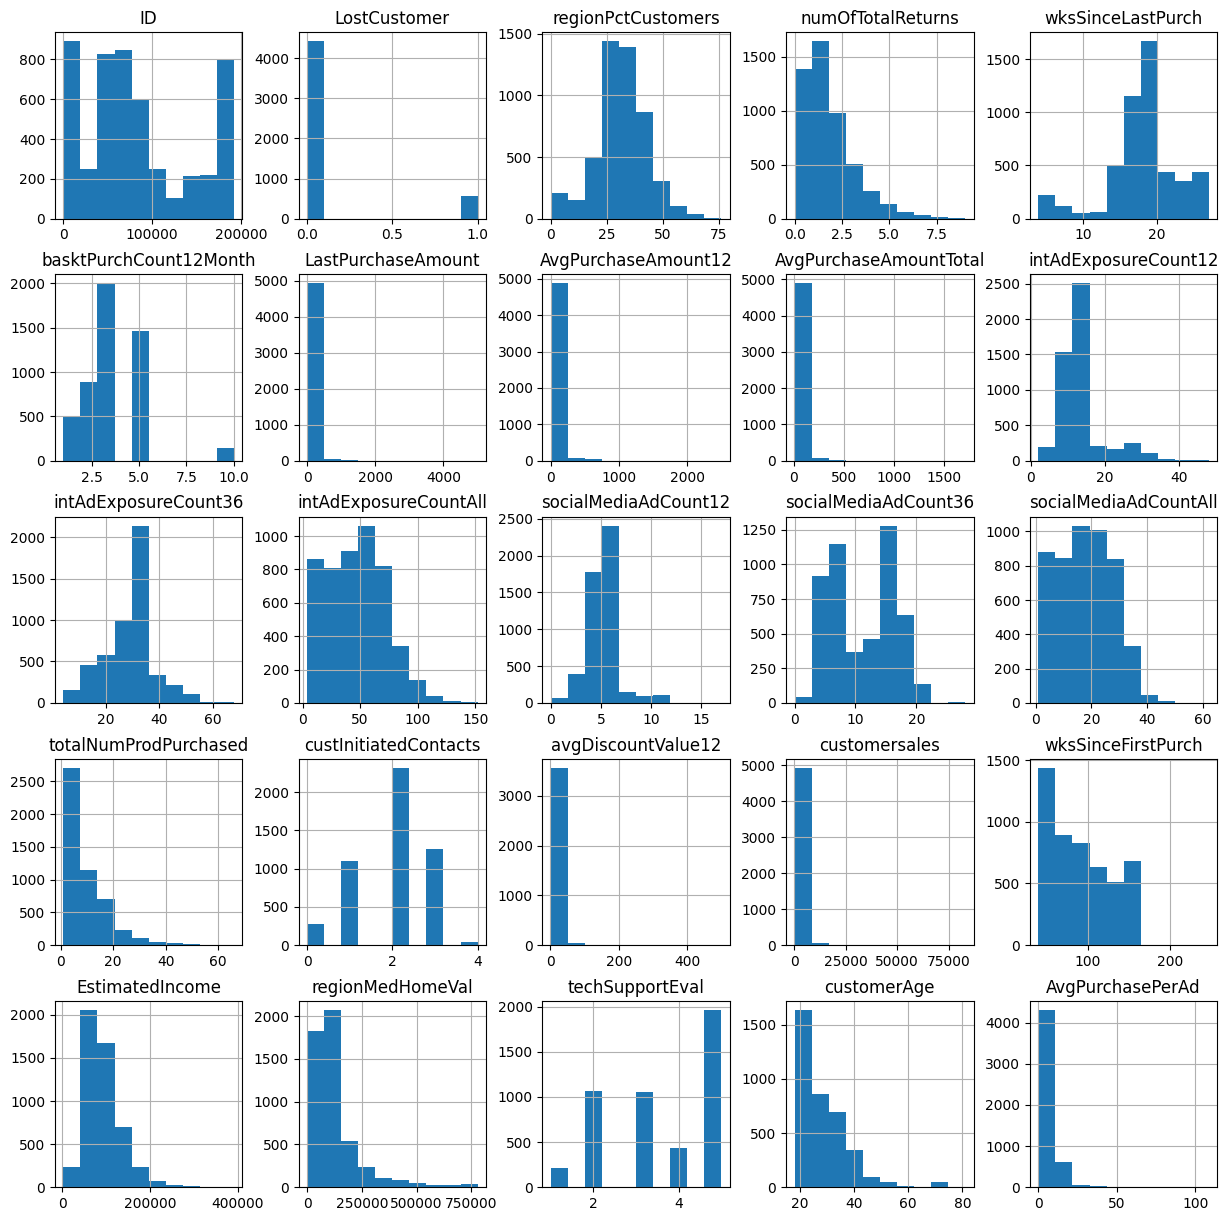

In [7]:
# Displays a histogram of all of the float and int columns

churn_df.hist(figsize = (15,15))

In [8]:
# Explores the distribution of the categorical columns

cat_columns = [col for col in churn_df.select_dtypes("object").columns if col not in ["birthDate", "Review_Text", "Title"]]

for col in cat_columns:
    print(churn_df[col].value_counts(), end = "\n\n")

customerGender
F    2637
M    2077
U     286
Name: count, dtype: int64

customerSubscrStat
Platinum    3945
Gold         793
Member       262
Name: count, dtype: int64

demHomeOwner
HomeOwner    2756
Unknown      2244
Name: count, dtype: int64



In [9]:
# Displays target variable distribution

churn_df["LostCustomer"].value_counts(normalize = True)

LostCustomer
0.0    0.8862
1.0    0.1138
Name: proportion, dtype: float64

<Axes: xlabel='LostCustomer', ylabel='count'>

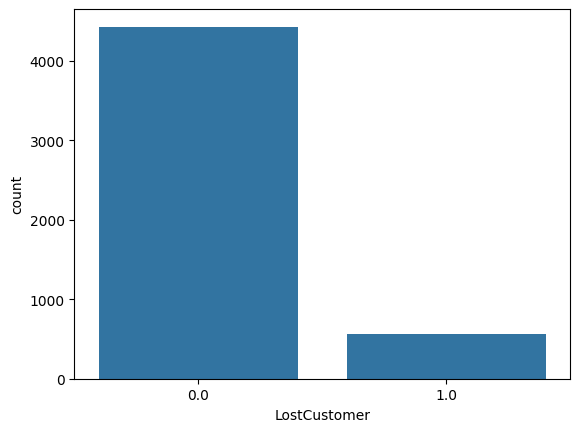

In [10]:
# Displays the target variable distribution

sns.countplot(churn_df, x = "LostCustomer")

In [11]:
def count_plots(data: pd.DataFrame, columns: list, figsize: tuple = (15,5), fig_per_row: int = 5) -> plt:
    """
    Generates a grid displaying barplots for all specified columns.    
    
    Parameters
    ----------
    data: pd.DataFrame
        Pandas dataframe containing data that will be visualized
    columns: list
        List containing the name of the column to be visualized.
    figsize: tuple
        Dimensions of the plot grid that will be generated
    fig_per_row: int
        How many figures a user wants per row. Default = 5.
    """
    # Determines plot dimensions. Defaults to 5 plots per row
    
    if len(columns) < fig_per_row:
        nrows, ncols = 1, fig_per_row
    else:
        nrows, ncols = ceil(len(columns) / fig_per_row), fig_per_row
    
    # Creates subplots based on specified dimensions
    
    fig, axs = plt.subplots(nrows = nrows, ncols = ncols, figsize = figsize)
    axs = axs.flatten()
    
    # Iterates through the columns and the created axes
    
    for col, ax in zip(columns, axs):
        sns.countplot(data = data, x = col, ax = ax)
        ax.set_title(f"{col} Count Plot")

    # Ensures there is no overlap between plots    
    
    plt.tight_layout()
    
    # Deletes any unused axes
    
    for ax in axs[len(columns):]:
        fig.delaxes(ax)
        
    return fig

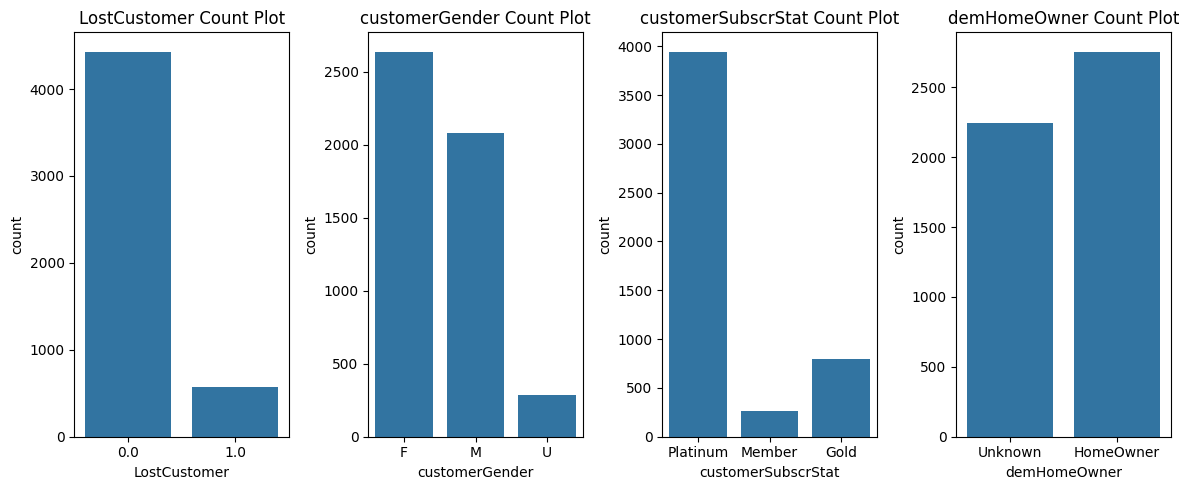

In [12]:
# Applies the count_plot function on the categorical columns

cat_count_plots = count_plots(churn_df, columns = ["LostCustomer"] + cat_columns)

### Extreme Observations

In [13]:
# Compute skewness and kurtosis for all numeric variables

skewness = churn_df.select_dtypes(["int", "float"]).skew()[2:]
kurtosis = churn_df.select_dtypes(["int", "float"]).kurtosis()[2:]

In [14]:
# Displays skewness
print("----------SKEWNESS----------", end = "\n\n")
print(skewness, end = "\n\n")

----------SKEWNESS----------

regionPctCustomers        -0.276819
numOfTotalReturns          1.353430
wksSinceLastPurch         -0.769708
basktPurchCount12Month     1.451794
LastPurchaseAmount        20.178165
AvgPurchaseAmount12       12.222168
AvgPurchaseAmountTotal    10.712645
intAdExposureCount12       1.968931
intAdExposureCount36      -0.002564
intAdExposureCountAll      0.358960
socialMediaAdCount12       0.928376
socialMediaAdCount36       0.051440
socialMediaAdCountAll      0.226121
totalNumProdPurchased      1.793127
custInitiatedContacts     -0.326428
avgDiscountValue12        13.092972
customersales             19.237148
wksSinceFirstPurch         0.323218
EstimatedIncome            1.291295
regionMedHomeVal           2.810775
techSupportEval           -0.274191
customerAge                1.969275
AvgPurchasePerAd           3.678838
dtype: float64



In [15]:
# Displays kurtosis

print("----------KURTOSIS----------")
print(kurtosis, end = "\n\n")

----------KURTOSIS----------
regionPctCustomers          1.126897
numOfTotalReturns           2.160976
wksSinceLastPurch           1.480670
basktPurchCount12Month      3.720589
LastPurchaseAmount        663.261180
AvgPurchaseAmount12       268.555711
AvgPurchaseAmountTotal    196.227004
intAdExposureCount12        4.671521
intAdExposureCount36        0.608148
intAdExposureCountAll      -0.356862
socialMediaAdCount12        4.810288
socialMediaAdCount36       -1.320594
socialMediaAdCountAll      -0.673961
totalNumProdPurchased       4.626991
custInitiatedContacts      -0.273435
avgDiscountValue12        264.285125
customersales             409.850200
wksSinceFirstPurch         -1.121705
EstimatedIncome             3.247220
regionMedHomeVal            9.625065
techSupportEval            -1.381629
customerAge                 5.805028
AvgPurchasePerAd           40.141760
dtype: float64



In [16]:
# Selecting highly non-normal columns based on Fisher's definition of kurtosis

high_skewness = skewness[(skewness > 3) | (skewness < -3)]
high_kurtosis = kurtosis[(kurtosis > 3) | (kurtosis < -3)]

In [17]:
# Displays results

print("----------SKEWNESS----------", end = "\n\n")
print(high_skewness, end = "\n\n")

print("----------KURTOSIS----------", end = "\n\n")
print(high_kurtosis, end = "\n\n")

print("----------HIGH BOTH----------", end = "\n\n")
skewed_cols = [col for col in high_skewness.index if col in high_kurtosis]
print(skewed_cols)

----------SKEWNESS----------

LastPurchaseAmount        20.178165
AvgPurchaseAmount12       12.222168
AvgPurchaseAmountTotal    10.712645
avgDiscountValue12        13.092972
customersales             19.237148
AvgPurchasePerAd           3.678838
dtype: float64

----------KURTOSIS----------

basktPurchCount12Month      3.720589
LastPurchaseAmount        663.261180
AvgPurchaseAmount12       268.555711
AvgPurchaseAmountTotal    196.227004
intAdExposureCount12        4.671521
socialMediaAdCount12        4.810288
totalNumProdPurchased       4.626991
avgDiscountValue12        264.285125
customersales             409.850200
EstimatedIncome             3.247220
regionMedHomeVal            9.625065
customerAge                 5.805028
AvgPurchasePerAd           40.141760
dtype: float64

----------HIGH BOTH----------

['LastPurchaseAmount', 'AvgPurchaseAmount12', 'AvgPurchaseAmountTotal', 'avgDiscountValue12', 'customersales', 'AvgPurchasePerAd']


array([[<Axes: title={'center': 'LastPurchaseAmount'}>,
        <Axes: title={'center': 'AvgPurchaseAmount12'}>,
        <Axes: title={'center': 'AvgPurchaseAmountTotal'}>],
       [<Axes: title={'center': 'avgDiscountValue12'}>,
        <Axes: title={'center': 'customersales'}>,
        <Axes: title={'center': 'AvgPurchasePerAd'}>]], dtype=object)

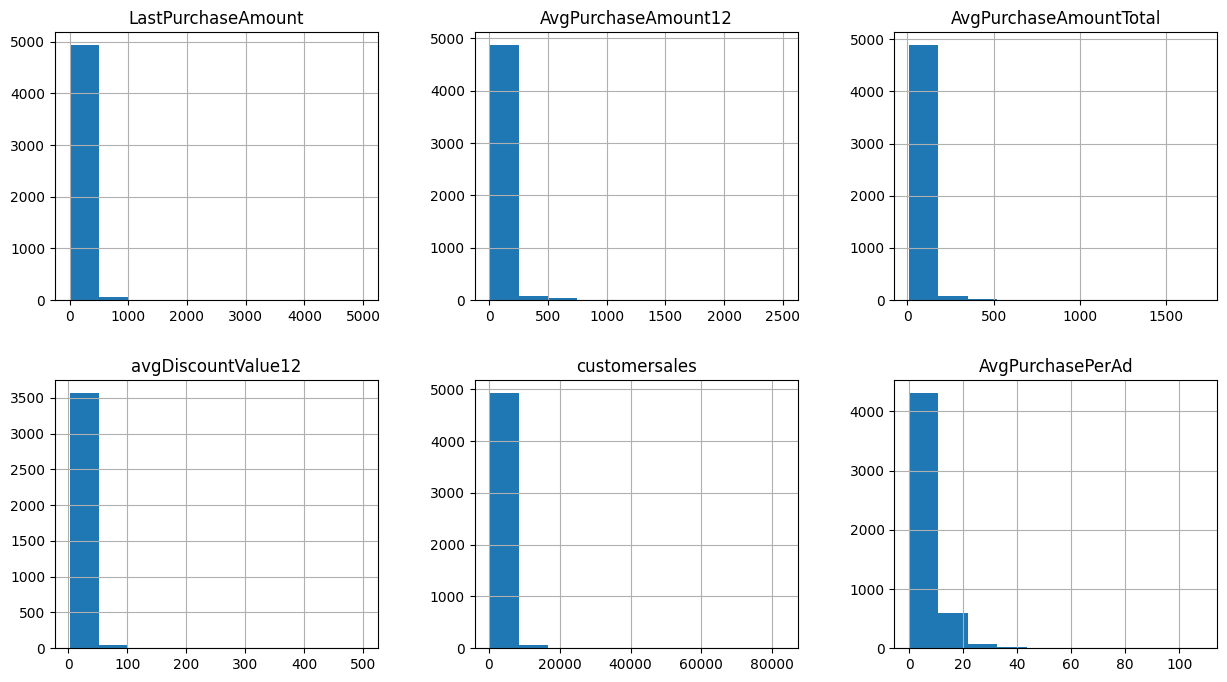

In [18]:
# Exploring Distrubution of skewed columns

churn_df[skewed_cols].hist(figsize = (15,8), layout = (2, 3))

In [19]:
# Define function to generate outlier plots

def box_plots(data: pd.DataFrame, columns: list, figsize: tuple = (15,5), fig_per_row: int = 5) -> plt:
    """
    Generates a grid displaying boxplots for all specified columns.    
    
    Parameters
    ----------
    data: pd.DataFrame
        Pandas dataframe containing data that will be visualized
    columns: list
        List containing the name of the column to be visualized.
    figsize: tuple
        Dimensions of the plot grid that will be generated
    fig_per_row: int
        How many figures a user wants per row. Default = 5.
    """
    # Determines plot dimensions. Defaults to 5 plots per row
    
    if len(columns) < fig_per_row:
        nrows, ncols = 1, fig_per_row
    else:
        nrows, ncols = ceil(len(columns) / fig_per_row), fig_per_row
    
    # Creates subplots based on specified dimensions
    
    fig, axs = plt.subplots(nrows = nrows, ncols = ncols, figsize = figsize)
    axs = axs.flatten()
    
    # Iterates through the columns and the created axes
    
    for col, ax in zip(columns, axs):
        sns.boxplot(data = data, y = col, ax = ax)
        ax.set_title(f"{col} Boxplot")

    # Ensures there is no overlap between plots    
    
    plt.tight_layout()
    
    # Deletes any unused axes
    
    for ax in axs[len(columns):]:
        fig.delaxes(ax)
        
    return fig

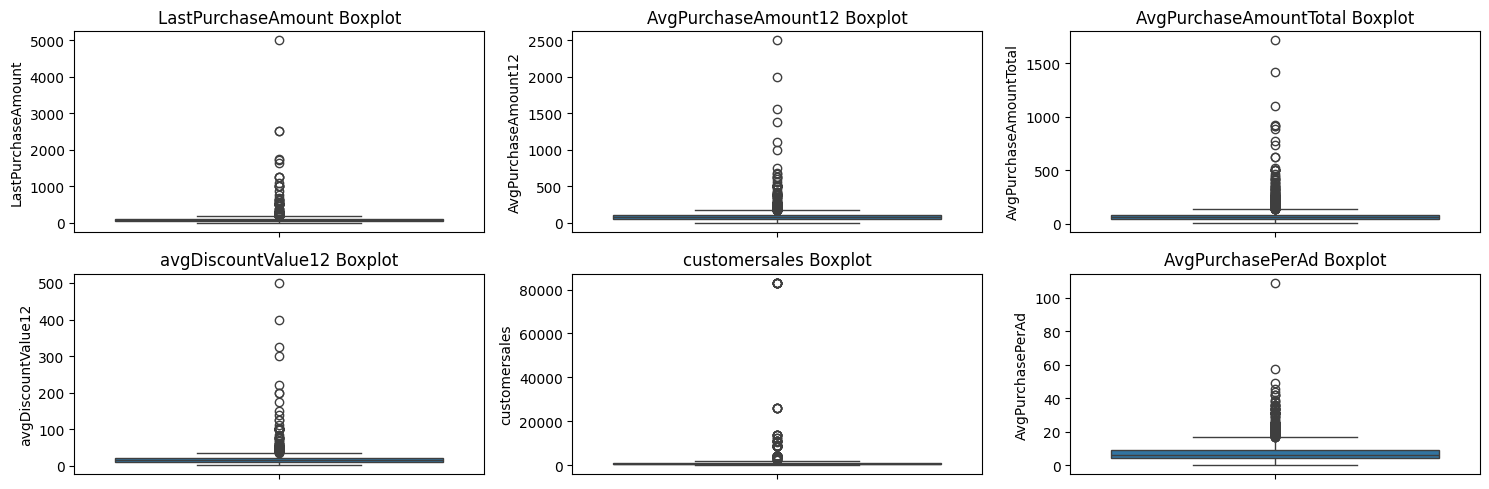

In [20]:
# Generates box and whisker plots

skewed_box_plots = box_plots(churn_df, skewed_cols, fig_per_row = 3)

### Exploring Missingness

In [21]:
# Displays the proportion of missing values

missing = churn_df.isna().sum()
missing = missing[missing > 0]/churn_df.shape[0]
missing

avgDiscountValue12    0.2764
birthDate             0.2518
techSupportEval       0.0540
Review_Text           0.8436
Title                 0.8656
customerAge           0.2518
dtype: float64

In [22]:
# Displays a sample of some of the missing columns

print(churn_df[missing.index].dtypes, end = "\n\n")
churn_df[missing.index].head()

avgDiscountValue12    float64
birthDate              object
techSupportEval       float64
Review_Text            object
Title                  object
customerAge           float64
dtype: object



,avgDiscountValue12,birthDate,techSupportEval,Review_Text,Title,customerAge
0,NaN,2004-11-13,3.0,NaN,NaN,20.0
1,15.0,1974-03-14,3.0,NaN,NaN,51.0
2,NaN,2006-02-22,2.0,NaN,NaN,19.0
3,8.0,2006-04-19,2.0,NaN,NaN,19.0
4,NaN,2002-02-23,2.0,NaN,NaN,23.0


array([[<Axes: title={'center': 'avgDiscountValue12'}>,
        <Axes: title={'center': 'techSupportEval'}>],
       [<Axes: title={'center': 'customerAge'}>, <Axes: >]], dtype=object)

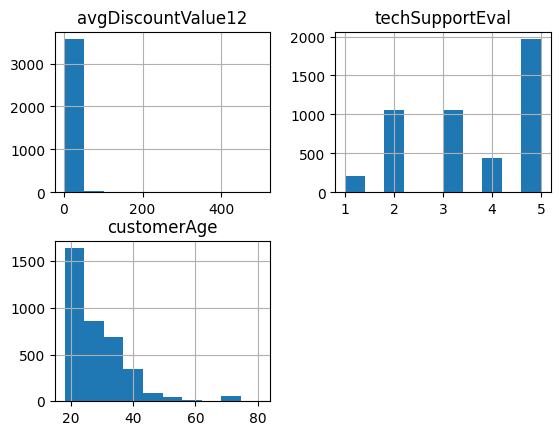

In [23]:
# Displays the distribution of the missing values

missing_list = missing.index.to_list()
churn_df[missing_list].hist()

In [24]:
# Computes the correlation between all variables

corr_df = churn_df.corr(numeric_only = True)

# Fills the diagonals to exlude them from the computation

np.fill_diagonal(corr_df.values, val = np.nan)

# Selects rows with high correlations

high_corr = corr_df[(corr_df > 0.9) | (corr_df < -0.9)]

# Drops rows, then columns, where the above threshold is not met

high_corr = high_corr.dropna(how = "all")
high_corr = high_corr.dropna(how = "all", axis = 1)

In [25]:
# Displays columns where a high correlation was found

high_corr.head()

,AvgPurchaseAmount12,intAdExposureCountAll,socialMediaAdCountAll,avgDiscountValue12
AvgPurchaseAmount12,NaN,NaN,NaN,0.982043
intAdExposureCountAll,NaN,NaN,0.945963,NaN
socialMediaAdCountAll,NaN,0.945963,NaN,NaN
avgDiscountValue12,0.982043,NaN,NaN,NaN


Text(0.5, 1.0, 'Correlation HeatMap')

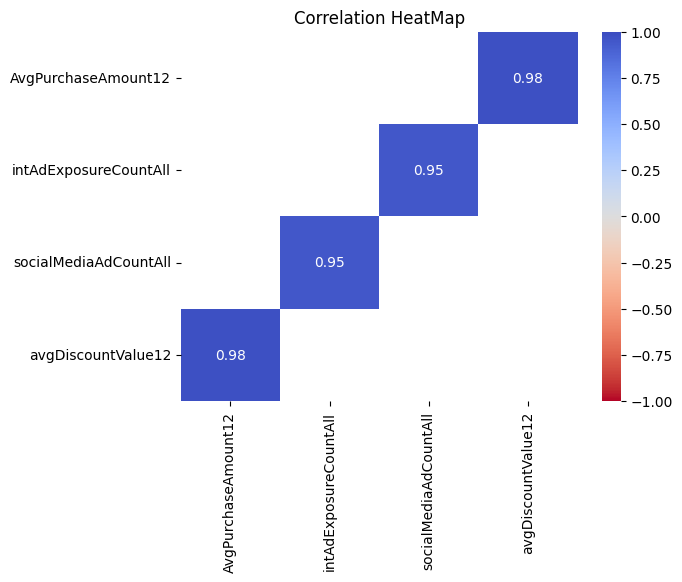

In [26]:
# Generates a heatmap using the correlation values

cmap = plt.get_cmap("coolwarm").reversed()
corr_plot = sns.heatmap(high_corr, vmin = -1, vmax = 1, annot=True, cmap=cmap)
corr_plot.set_title("Correlation HeatMap")